
# Car Price Prediction with Machine Learning

**Oasis Infobyte — Data Science Internship**  
**Task 3 — Car Price Prediction with Machine Learning**  
**Author:** Md. Zayed Hossain

This notebook builds an end-to-end regression workflow to predict the selling price of a used vehicle from attributes such as brand, age, mileage, fuel type, seller type, transmission, ownership, and present price.



## 1. Objective

Build and compare regression models that predict a used vehicle's selling price. This workflow follows the Oasis Infobyte Task 3 checklist: data cleaning, feature engineering, EDA, categorical encoding, train/test split, multiple regression models, MAE/RMSE/R² evaluation, and feature-importance analysis.



## 2. Dataset

The project uses the classic **Vehicle dataset from CarDekho** with 301 records and 9 original columns. The Oasis task guide recommends this dataset.

The notebook first checks for `data/car_data.csv`. If it is missing, it downloads a public CSV mirror and saves a local copy automatically.

Original dataset page: `https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho`

> The price columns are kept in the dataset's original unit, commonly documented as lakh INR.


## 3. Import Libraries and Project Settings

In [1]:

from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
TEST_SIZE = 0.20
REFERENCE_YEAR = 2026

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
IMAGES_DIR = PROJECT_ROOT / 'images'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
for directory in (DATA_DIR, IMAGES_DIR, OUTPUTS_DIR):
    directory.mkdir(exist_ok=True)

LOCAL_DATA = DATA_DIR / 'car_data.csv'
DATA_URL = 'https://raw.githubusercontent.com/RimjimRazdan/cars_price_prediction/refs/heads/master/car%20data.csv'


## 4. Load the Dataset

In [2]:

if LOCAL_DATA.exists():
    raw_df = pd.read_csv(LOCAL_DATA)
    source_used = f'Local file: {LOCAL_DATA}'
else:
    raw_df = pd.read_csv(DATA_URL)
    raw_df.to_csv(LOCAL_DATA, index=False)
    source_used = f'Public mirror: {DATA_URL}'

print(source_used)
print('Dataset shape:', raw_df.shape)
display(raw_df.head())


Local file: /content/data/car_data.csv
Dataset shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



## 5. Initial Inspection

Inspect shape, dtypes, missing values, duplicate rows, and descriptive statistics before cleaning.


In [3]:

print('Shape:', raw_df.shape)
print('\nData types:')
print(raw_df.dtypes)
print('\nNull values per column:')
display(raw_df.isna().sum().to_frame('null_count'))
print('Exact duplicate rows:', raw_df.duplicated().sum())
print('\nDescriptive statistics:')
display(raw_df.describe(include='all').T)


Shape: (301, 9)

Data types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

Null values per column:


,null_count
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


Exact duplicate rows: 2

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0



## 6. Data Cleaning

- Rename columns to consistent `snake_case`.
- Remove extra whitespace from text.
- Normalise category labels.
- Convert expected numeric columns safely.
- Handle missing values if present.
- Remove exact duplicate rows and document the count.


In [4]:

df = raw_df.copy()
df.columns = [
    'car_name', 'year', 'selling_price', 'present_price', 'kms_driven',
    'fuel_type', 'seller_type', 'transmission', 'owner'
]

for col in ['car_name', 'fuel_type', 'seller_type', 'transmission']:
    df[col] = df[col].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)
for col in ['fuel_type', 'seller_type', 'transmission']:
    df[col] = df[col].str.title()
for col in ['year', 'selling_price', 'present_price', 'kms_driven', 'owner']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

missing_before = df.isna().sum()
if missing_before.sum() > 0:
    df = df.dropna(subset=['selling_price', 'year'])
    for col in ['present_price', 'kms_driven', 'owner']:
        df[col] = df[col].fillna(df[col].median())
    for col in ['car_name', 'fuel_type', 'seller_type', 'transmission']:
        modes = df[col].mode(dropna=True)
        if len(modes):
            df[col] = df[col].fillna(modes.iloc[0])

duplicates_removed = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

print('Missing values before cleaning:')
display(missing_before.to_frame('count'))
print('Duplicates removed:', duplicates_removed)
print('Cleaned shape:', df.shape)
print('Remaining missing values:', int(df.isna().sum().sum()))


Missing values before cleaning:


,count
car_name,0
year,0
selling_price,0
present_price,0
kms_driven,0
fuel_type,0
seller_type,0
transmission,0
owner,0


Duplicates removed: 2
Cleaned shape: (299, 9)
Remaining missing values: 0



## 7. Feature Engineering

The Oasis task requires **car age** and **brand**.

- `car_age = 2026 - year`
- `brand` is extracted from the first token in `car_name`.

This simple brand rule is transparent for an internship project; a production pipeline would use a manufacturer dictionary for multi-word brands.


In [5]:
df['car_age'] = REFERENCE_YEAR - df['year']

maruti_models = {
    'ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza',
    's cross', 'alto 800', 'ertiga', 'dzire', 'alto k10',
    'ignis', '800', 'baleno', 'omni'
}

toyota_models = {
    'fortuner', 'innova', 'corolla altis', 'etios cross',
    'etios g', 'etios liva', 'corolla', 'etios gd',
    'camry', 'land cruiser'
}

hyundai_models = {
    'i20', 'grand i10', 'i10', 'eon',
    'xcent', 'elantra', 'creta', 'verna'
}

honda_car_models = {
    'city', 'brio', 'amaze', 'jazz'
}

def extract_brand(car_name):
    name = ' '.join(str(car_name).strip().lower().split())

    if name in maruti_models:
        return 'Maruti Suzuki'
    if name in toyota_models:
        return 'Toyota'
    if name in hyundai_models:
        return 'Hyundai'
    if name in honda_car_models or name.startswith('activa'):
        return 'Honda'

    prefix_brands = {
        'royal enfield': 'Royal Enfield',
        'hero honda': 'Hero Honda',
        'um': 'UM',
        'ktm': 'KTM',
        'tvs': 'TVS',
        'bajaj': 'Bajaj',
        'hyosung': 'Hyosung',
        'mahindra': 'Mahindra',
        'honda': 'Honda',
        'yamaha': 'Yamaha',
        'hero': 'Hero',
        'suzuki': 'Suzuki'
    }

    for prefix, brand in prefix_brands.items():
        if name == prefix or name.startswith(prefix + ' '):
            return brand

    return name.split()[0].title()

df['brand'] = df['car_name'].apply(extract_brand)

print('Negative car ages:', int((df['car_age'] < 0).sum()))
print('Extracted brands:', df['brand'].nunique())

display(
    df[['car_name', 'brand', 'year', 'car_age', 'selling_price']].head(12)
)

Negative car ages: 0
Extracted brands: 15


,car_name,brand,year,car_age,selling_price
0,ritz,Maruti Suzuki,2014,12,3.35
1,sx4,Maruti Suzuki,2013,13,4.75
2,ciaz,Maruti Suzuki,2017,9,7.25
3,wagon r,Maruti Suzuki,2011,15,2.85
4,swift,Maruti Suzuki,2014,12,4.60
5,vitara brezza,Maruti Suzuki,2018,8,9.25
6,ciaz,Maruti Suzuki,2015,11,6.75
7,s cross,Maruti Suzuki,2015,11,6.50
8,ciaz,Maruti Suzuki,2016,10,8.75
9,ciaz,Maruti Suzuki,2015,11,7.45


## 8. Exploratory Data Analysis (EDA)

### 8.1 Distribution of Selling Prices

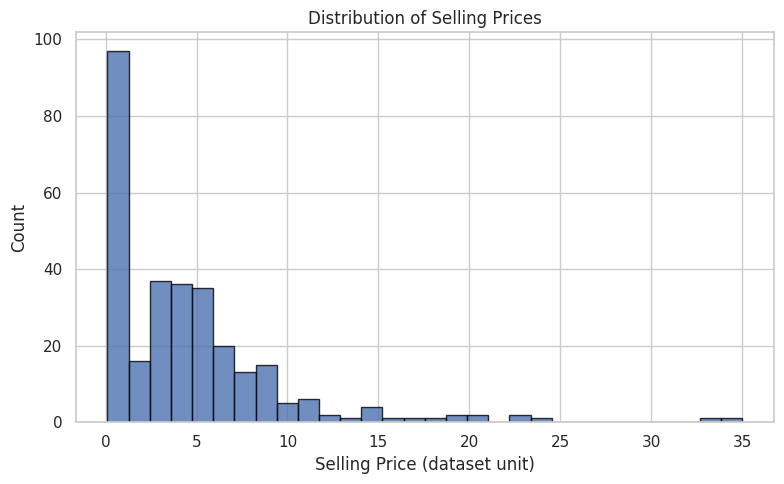

count    299.000000
mean       4.589632
std        4.984240
min        0.100000
25%        0.850000
50%        3.510000
75%        6.000000
max       35.000000
Name: selling_price, dtype: float64


In [6]:

plt.figure(figsize=(8,5))
plt.hist(df['selling_price'], bins=30, edgecolor='black', alpha=0.8)
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price (dataset unit)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'selling_price_distribution.png', dpi=180, bbox_inches='tight')
plt.show()
print(df['selling_price'].describe())


### 8.2 Selling Price vs Fuel Type

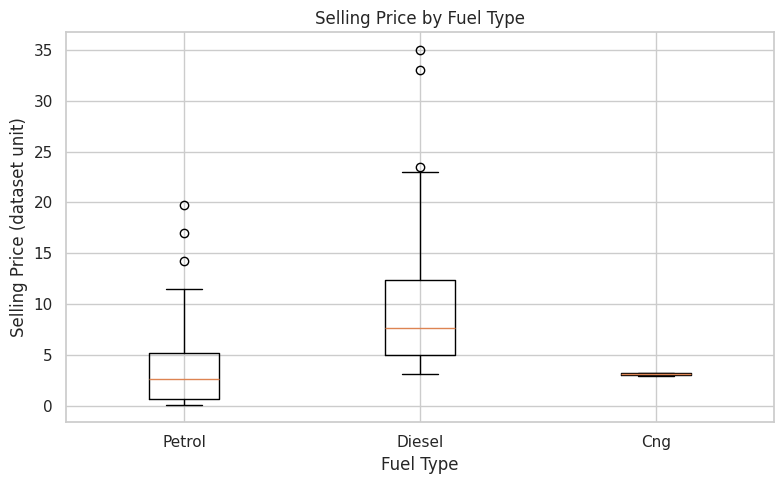

In [7]:

labels = list(df['fuel_type'].dropna().unique())
groups = [df.loc[df['fuel_type'] == label, 'selling_price'] for label in labels]
plt.figure(figsize=(8,5))
plt.boxplot(groups, tick_labels=labels)
plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (dataset unit)')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'price_vs_fuel_type_boxplot.png', dpi=180, bbox_inches='tight')
plt.show()


### 8.3 Selling Price vs Car Age

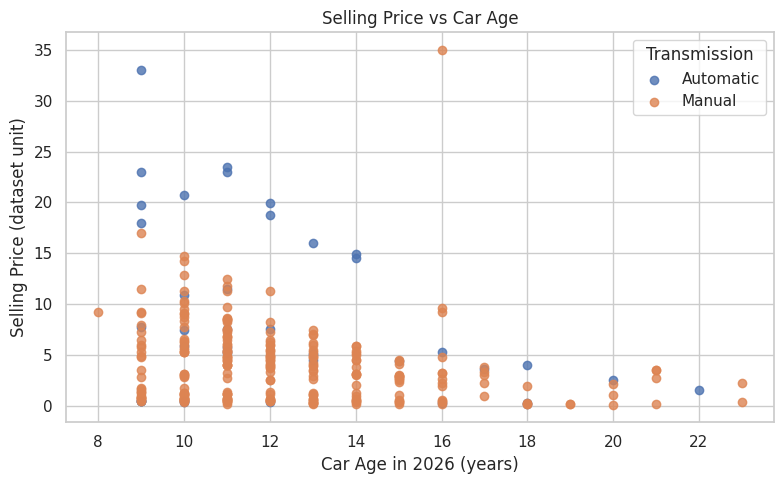

In [8]:

plt.figure(figsize=(8,5))
for transmission, subset in df.groupby('transmission'):
    plt.scatter(subset['car_age'], subset['selling_price'], alpha=0.8, label=transmission)
plt.title('Selling Price vs Car Age')
plt.xlabel(f'Car Age in {REFERENCE_YEAR} (years)')
plt.ylabel('Selling Price (dataset unit)')
plt.legend(title='Transmission')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'price_vs_car_age_scatter.png', dpi=180, bbox_inches='tight')
plt.show()


### 8.4 Feature Correlation Heatmap

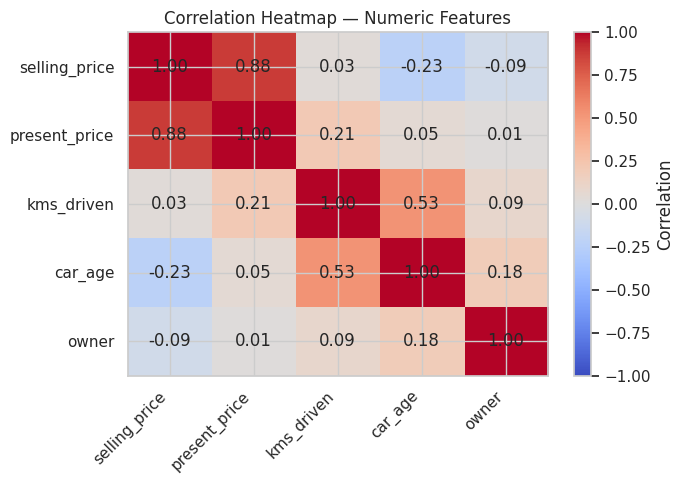

In [9]:

corr_cols = ['selling_price', 'present_price', 'kms_driven', 'car_age', 'owner']
corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(7,5))
im = plt.imshow(corr, aspect='auto', vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(im, label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center')
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'feature_correlation_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()


### 8.5 Bonus: Brand-Level Price Analysis

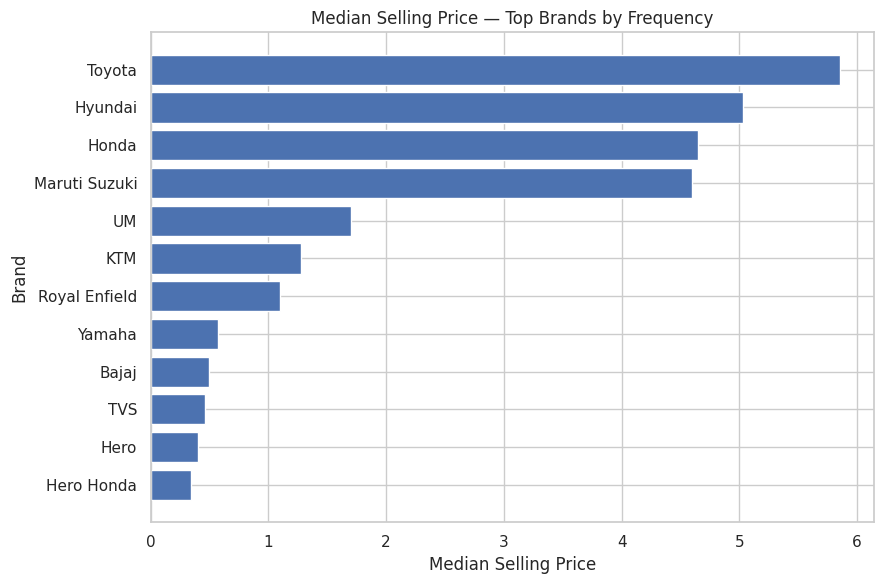

,brand,vehicle_count,median_selling_price
3,Honda,70,4.650
5,Hyundai,50,5.030
8,Maruti Suzuki,49,4.600
12,Toyota,49,5.850
0,Bajaj,25,0.500
9,Royal Enfield,17,1.100
1,Hero,13,0.400
11,TVS,8,0.465
14,Yamaha,8,0.575
6,KTM,4,1.275


In [10]:

brand_summary = (
    df.groupby('brand', as_index=False)
      .agg(vehicle_count=('selling_price', 'size'), median_selling_price=('selling_price', 'median'))
      .sort_values(['vehicle_count','median_selling_price'], ascending=False)
)
top_brands = brand_summary.head(12).sort_values('median_selling_price')
plt.figure(figsize=(9,6))
plt.barh(top_brands['brand'], top_brands['median_selling_price'])
plt.title('Median Selling Price — Top Brands by Frequency')
plt.xlabel('Median Selling Price')
plt.ylabel('Brand')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'brand_median_price.png', dpi=180, bbox_inches='tight')
plt.show()
display(top_brands.sort_values('vehicle_count', ascending=False))



## 9. Prepare Features and Target

Numeric features: present price, kilometres driven, car age, owner count.  
Categorical features: brand, fuel type, seller type, transmission.

Categorical variables are handled with One-Hot Encoding inside a `ColumnTransformer`.


In [11]:

features = ['present_price','kms_driven','car_age','owner','brand','fuel_type','seller_type','transmission']
target = 'selling_price'
X = df[features].copy()
y = df[target].copy()

numeric_features = ['present_price','kms_driven','car_age','owner']
categorical_features = ['brand','fuel_type','seller_type','transmission']
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print('Training set:', X_train.shape)
print('Test set:', X_test.shape)


Training set: (239, 8)
Test set: (60, 8)



## 10. Train Multiple Regression Models

The project compares Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor.


In [12]:

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(
        random_state=RANDOM_STATE, n_estimators=250, learning_rate=0.04, max_depth=2
    )
}

pipelines = {
    name: Pipeline([('preprocessor', preprocessor), ('model', model)])
    for name, model in models.items()
}

results = []
predictions = {}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    predictions[name] = pred
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred),
        'CV_R2_Mean': cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2').mean()
    })

results_df = pd.DataFrame(results).sort_values(['R2','RMSE'], ascending=[False,True]).reset_index(drop=True)
display(results_df.style.format({'MAE':'{:.4f}','RMSE':'{:.4f}','R2':'{:.4f}','CV_R2_Mean':'{:.4f}'}))
results_df.to_csv(OUTPUTS_DIR / 'model_comparison.csv', index=False)


,Model,MAE,RMSE,R2,CV_R2_Mean
0,Linear Regression,1.5196,2.5399,0.7497,0.8638
1,Gradient Boosting,1.2582,2.6362,0.7304,0.8985
2,Random Forest,1.3805,3.3164,0.5733,0.8964


## 11. Model Comparison

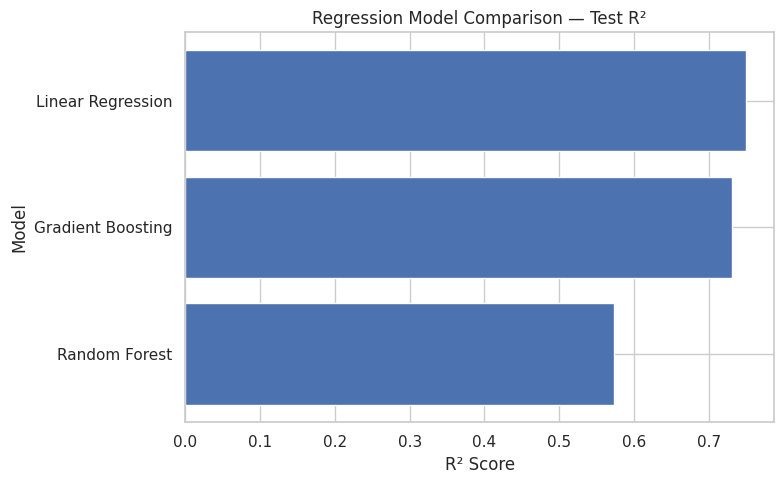

In [13]:

plot_df = results_df.sort_values('R2')
plt.figure(figsize=(8,5))
plt.barh(plot_df['Model'], plot_df['R2'])
plt.title('Regression Model Comparison — Test R²')
plt.xlabel('R² Score')
plt.ylabel('Model')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'model_comparison_r2.png', dpi=180, bbox_inches='tight')
plt.show()


## 12. Select the Best Model

In [14]:

best_name = results_df.iloc[0]['Model']
best_pipeline = pipelines[best_name]
best_pred = predictions[best_name]
best_mae = mean_absolute_error(y_test, best_pred)
best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_r2 = r2_score(y_test, best_pred)
print('Best model:', best_name)
print(f'MAE: {best_mae:.4f}')
print(f'RMSE: {best_rmse:.4f}')
print(f'R²: {best_r2:.4f}')


Best model: Linear Regression
MAE: 1.5196
RMSE: 2.5399
R²: 0.7497


## 13. Actual vs Predicted

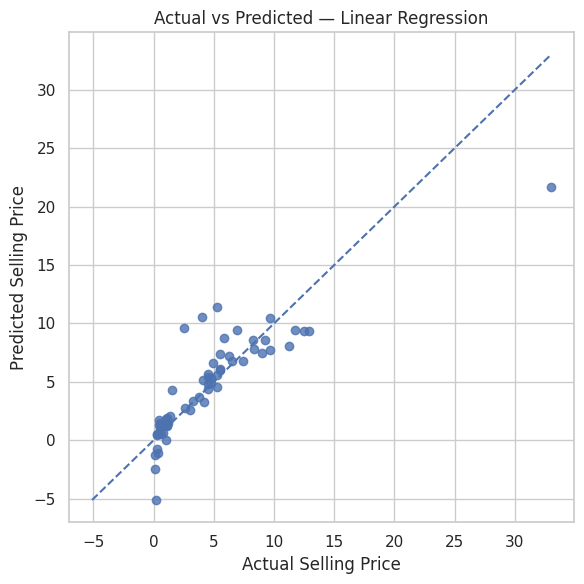

In [15]:

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred, alpha=0.8)
low = min(float(y_test.min()), float(best_pred.min()))
high = max(float(y_test.max()), float(best_pred.max()))
plt.plot([low,high],[low,high], linestyle='--', linewidth=1.5)
plt.title(f'Actual vs Predicted — {best_name}')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'actual_vs_predicted.png', dpi=180, bbox_inches='tight')
plt.show()


## 14. Residual Plot

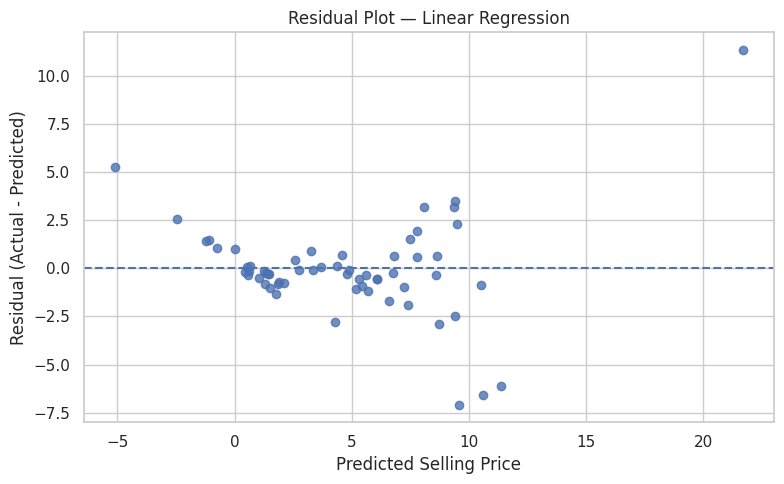

In [16]:

residuals = y_test.to_numpy() - best_pred
plt.figure(figsize=(8,5))
plt.scatter(best_pred, residuals, alpha=0.8)
plt.axhline(0, linestyle='--', linewidth=1.5)
plt.title(f'Residual Plot — {best_name}')
plt.xlabel('Predicted Selling Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'residual_plot.png', dpi=180, bbox_inches='tight')
plt.show()


## 15. Feature Importance for the Best Model

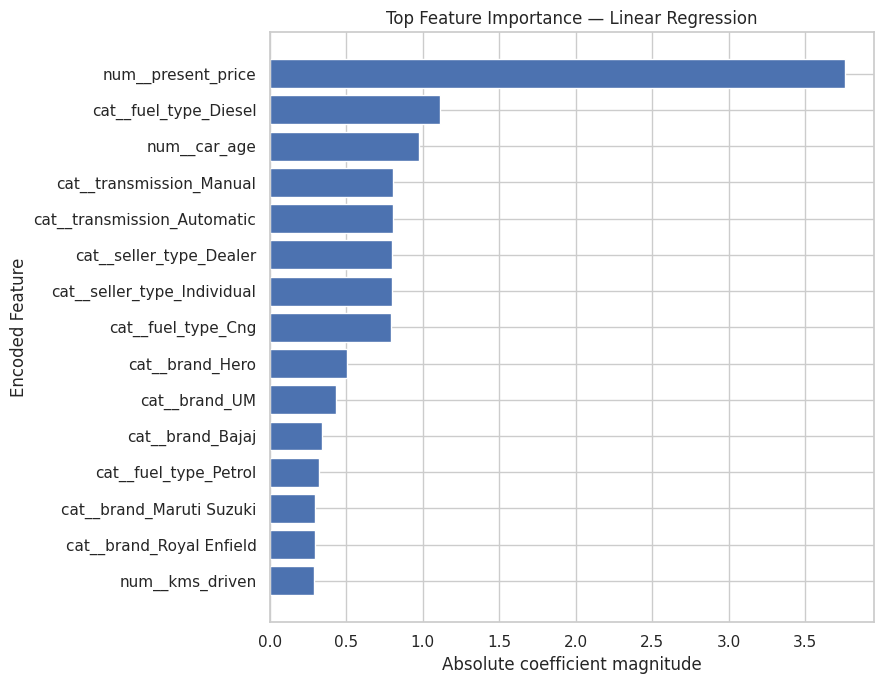

,Feature,Importance
0,num__present_price,3.761003
1,cat__fuel_type_Diesel,1.110854
2,num__car_age,0.979156
3,cat__transmission_Manual,0.803595
4,cat__transmission_Automatic,0.803595
5,cat__seller_type_Dealer,0.802549
6,cat__seller_type_Individual,0.802549
7,cat__fuel_type_Cng,0.791329
8,cat__brand_Hero,0.506154
9,cat__brand_UM,0.432350


In [17]:

fitted_preprocessor = best_pipeline.named_steps['preprocessor']
fitted_model = best_pipeline.named_steps['model']
feature_names = fitted_preprocessor.get_feature_names_out()

if hasattr(fitted_model, 'feature_importances_'):
    importance_values = fitted_model.feature_importances_
    importance_label = 'Feature importance'
elif hasattr(fitted_model, 'coef_'):
    importance_values = np.abs(np.ravel(fitted_model.coef_))
    importance_label = 'Absolute coefficient magnitude'
else:
    raise AttributeError('Best model does not expose feature importance or coefficients.')

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_values})
importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
importance_df.to_csv(OUTPUTS_DIR / 'feature_importance.csv', index=False)

top_features = importance_df.head(15).sort_values('Importance')
plt.figure(figsize=(9,7))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title(f'Top Feature Importance — {best_name}')
plt.xlabel(importance_label)
plt.ylabel('Encoded Feature')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'feature_importance_best_model.png', dpi=180, bbox_inches='tight')
plt.show()
display(importance_df.head(15))


## 16. Save Predictions and Model

In [18]:

prediction_df = X_test.copy()
prediction_df['actual_selling_price'] = y_test.values
prediction_df['predicted_selling_price'] = best_pred
prediction_df['residual'] = prediction_df['actual_selling_price'] - prediction_df['predicted_selling_price']
prediction_df.to_csv(OUTPUTS_DIR / 'test_predictions.csv', index=False)
joblib.dump(best_pipeline, OUTPUTS_DIR / 'best_car_price_model.joblib')

summary_text = (
    f'Best Model: {best_name}\n'
    f'Test MAE: {best_mae:.4f}\n'
    f'Test RMSE: {best_rmse:.4f}\n'
    f'Test R2: {best_r2:.4f}\n'
    f'Train rows: {len(X_train)}\n'
    f'Test rows: {len(X_test)}\n'
)
(OUTPUTS_DIR / 'best_model_summary.txt').write_text(summary_text, encoding='utf-8')
print(summary_text)


Best Model: Linear Regression
Test MAE: 1.5196
Test RMSE: 2.5399
Test R2: 0.7497
Train rows: 239
Test rows: 60



## 17. Final Interpretation

In [19]:

top3 = importance_df.head(3)['Feature'].tolist()
final_text = (
    '### Final Result\n\n'
    f'- **Best-performing model:** {best_name}\n'
    f'- **MAE:** {best_mae:.4f}\n'
    f'- **RMSE:** {best_rmse:.4f}\n'
    f'- **R²:** {best_r2:.4f}\n'
    f'- **Most influential encoded features:** {", ".join(top3)}\n\n'
    'The project covers cleaning, feature engineering, EDA, categorical encoding, multiple regression models, quantitative evaluation, and feature-importance analysis.'
)
display(Markdown(final_text))


### Final Result

- **Best-performing model:** Linear Regression
- **MAE:** 1.5196
- **RMSE:** 2.5399
- **R²:** 0.7497
- **Most influential encoded features:** num__present_price, cat__fuel_type_Diesel, num__car_age

The project covers cleaning, feature engineering, EDA, categorical encoding, multiple regression models, quantitative evaluation, and feature-importance analysis.


## 18. Checklist Coverage

- ✅ Suitable CarDekho dataset
- ✅ Null handling, duplicate handling, and category normalisation
- ✅ Car age engineered from year
- ✅ Brand extracted from vehicle name
- ✅ Selling-price distribution
- ✅ Price vs fuel-type box plot
- ✅ Price vs car-age scatter plot
- ✅ One-Hot Encoding for categorical variables
- ✅ Feature correlation heatmap
- ✅ Train/test split
- ✅ At least two regression models (three are used)
- ✅ MAE, RMSE, and R² evaluation
- ✅ Feature-importance chart for the best model
- ✅ Clean, commented Jupyter Notebook
